In [48]:
import pandas as pd
df=pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


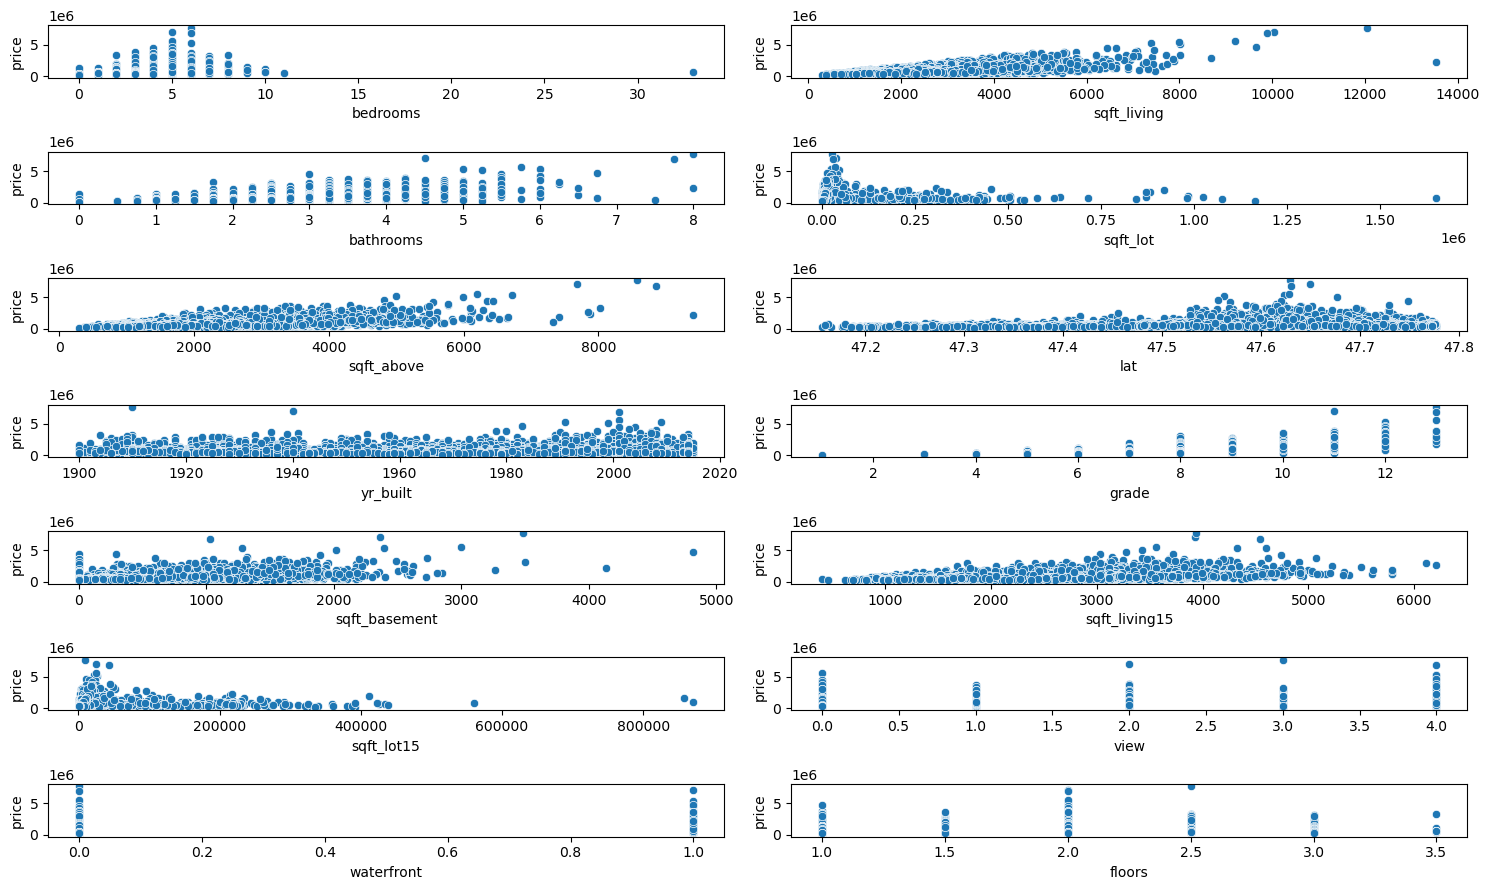

In [49]:
#checking linear relationships
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(7,2, figsize=(15, 9))

sns.scatterplot(data=df,x=df["bedrooms"],y=df["price"],ax=axes[0,0])
sns.scatterplot(data=df,x=df["sqft_living"],y=df["price"],ax=axes[0,1])
sns.scatterplot(data=df,x=df["bathrooms"],y=df["price"],ax=axes[1,0])
sns.scatterplot(data=df,x=df["sqft_lot"],y=df["price"],ax=axes[1,1])
sns.scatterplot(data=df,x=df["sqft_above"],y=df["price"],ax=axes[2,0])
sns.scatterplot(data=df,x=df["lat"],y=df["price"],ax=axes[2,1])
sns.scatterplot(data=df,x=df["yr_built"],y=df["price"],ax=axes[3,0])
sns.scatterplot(data=df,x=df["grade"],y=df["price"],ax=axes[3,1])
sns.scatterplot(data=df,x=df["sqft_basement"],y=df["price"],ax=axes[4,0])
sns.scatterplot(data=df,x=df["sqft_living15"],y=df["price"],ax=axes[4,1])
sns.scatterplot(data=df,x=df["sqft_lot15"],y=df["price"],ax=axes[5,0])
sns.scatterplot(data=df,x=df["view"],y=df["price"],ax=axes[5,1])
sns.scatterplot(data=df,x=df["waterfront"],y=df["price"],ax=axes[6,0])
sns.scatterplot(data=df,x=df["floors"],y=df["price"],ax=axes[6,1])
plt.tight_layout()
plt.tight_layout()
plt.show()

In [50]:
#find the corealtions between the features and select best feature for preprocessing
matrix = df.corr()
matrix

C:\Users\sreev\AppData\Local\Temp\ipykernel_33596\313856269.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  matrix = df.corr()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010830,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477616,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685363,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876644,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183511,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523899,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072074,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167648,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158206,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [51]:
x=df[["sqft_living","grade","bathrooms","lat","sqft_basement"]]
y=df["price"]

In [66]:
#scaling data 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [68]:
X_train,Y_train,X_test,Y_test


(       sqft_living  grade  bathrooms      lat  sqft_basement
 6325          1780      9       1.75  47.3670              0
 13473         1000      6       1.00  47.5520            200
 17614         1080      6       1.00  47.4838             90
 16970         2090      7       2.25  47.3951            810
 20868         1741      8       2.50  47.7043            295
 ...            ...    ...        ...      ...            ...
 11964         1000      7       1.50  47.7144              0
 21575         3087      8       2.50  47.2974              0
 5390          2120      7       2.50  47.6810              0
 860            380      5       0.75  47.4810              0
 15795         3130      7       2.50  47.3837              0
 
 [17290 rows x 5 columns],
 6325     325000.0
 13473    257000.0
 17614    228500.0
 16970    288000.0
 20868    479000.0
            ...   
 11964    378000.0
 21575    399950.0
 5390     575000.0
 860      245000.0
 15795    315000.0
 Name: price, Leng

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
X_train_scaled,X_test_scaled

(array([[-0.32393262,  1.15024328, -0.47445144, -1.39660754, -0.65631017],
        [-1.18365301, -1.41315603, -1.45258323, -0.06017248, -0.20043274],
        [-1.09547656, -1.41315603, -1.45258323, -0.55284746, -0.45116533],
        ...,
        [ 0.05081729, -0.55868959,  0.50368036,  0.87172008, -0.65631017],
        [-1.8670205 , -2.26762247, -1.77862716, -0.57307459, -0.65631017],
        [ 1.16404497, -0.55868959,  0.50368036, -1.27596719, -0.65631017]]),
 array([[-0.00429299,  0.29577684,  0.17763643, -0.87792626, -0.65631017],
        [ 0.91053768,  0.29577684,  1.15576822,  0.85293775,  1.78263404],
        [ 1.86945657,  2.85917616,  0.50368036,  0.03084958, -0.65631017],
        ...,
        [ 0.39690986,  0.29577684,  0.50368036, -1.97163582, -0.65631017],
        [ 0.19410402,  0.29577684, -0.47445144,  0.23023125, -0.65631017],
        [ 0.54680982,  0.29577684,  0.50368036, -2.01859165, -0.65631017]]))

In [71]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[172462.99,108305.49,-19363.28, 88404.7 , 20090.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.378e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[213.01,132.89,122.16, 74.55, 54.19]"


In [72]:
y_pred=lr.predict(X_test_scaled)

In [73]:
y_pred,Y_test

(array([ 474824.09252737,  815674.06382096, 1149633.54964787, ...,
         441014.39344385,  619633.12604807,  462715.47468131]),
 735       365000.0
 2830      865000.0
 4106     1038000.0
 16218    1490000.0
 19964     711000.0
            ...    
 13674     338000.0
 20377     673000.0
 8805      285000.0
 10168     605000.0
 2522      356500.0
 Name: price, Length: 4323, dtype: float64)

C:\Users\sreev\AppData\Local\Temp\ipykernel_33596\1897921534.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred)


<Axes: ylabel='Density'>

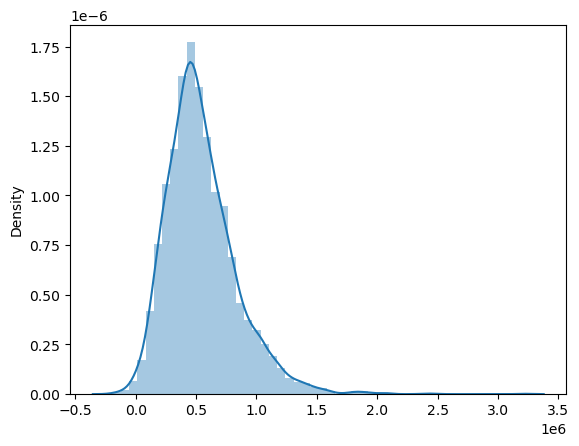

In [74]:
sns.distplot(y_pred)

C:\Users\sreev\AppData\Local\Temp\ipykernel_33596\336957920.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_test)


<Axes: xlabel='price', ylabel='Density'>

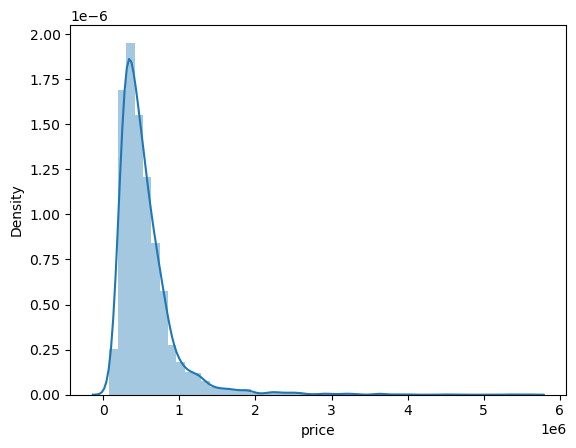

In [75]:
sns.distplot(Y_test)

In [78]:
#R2 SCORE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(Y_test, y_pred)

mse = mean_squared_error(Y_test, y_pred)

rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

In [79]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²   :", r2)

MAE : 147122.88411333988
MSE : 60348316118.457466
RMSE: 245658.9426795969
R²   : 0.6008094420262113


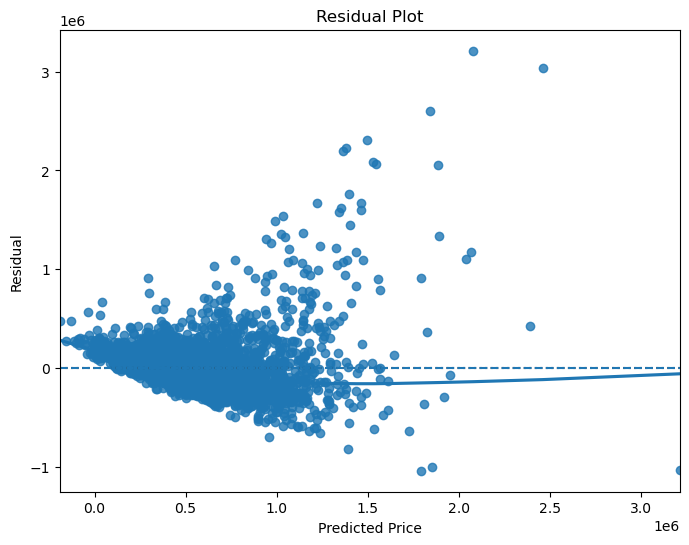

In [84]:
plt.figure(figsize=(8, 6))

sns.residplot(
    x=y_pred,
    y=residuals,
    lowess=True
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

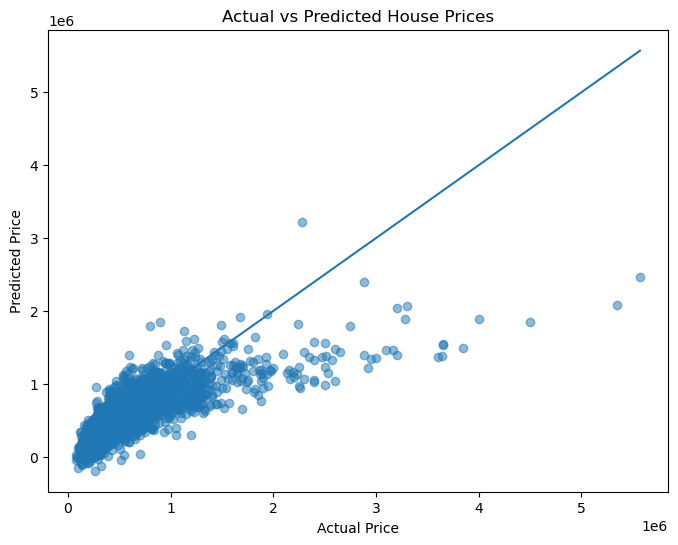

In [85]:


plt.figure(figsize=(8, 6))

plt.scatter(Y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

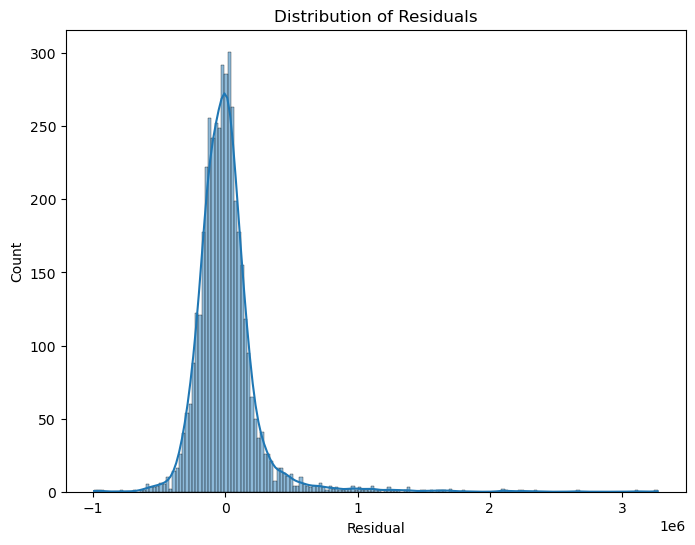

In [86]:
#residual distribution
plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()